In [21]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist

from cellina import CellinaModel
from utils import set_seed

In [4]:
set_seed(0)

In [5]:
adata = sc.read_h5ad("/data2/a330d/datasets/synthetic_spatial_adata_processed.h5ad")

In [6]:
CellinaModel.setup_anndata(adata,
                           batch_key="batch",
                           labels_key='cell_type', 
                           domains_key='region', 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


In [7]:
epochs = 100

model = CellinaModel(
            adata, n_latent=64, classifier_lambda=1e5, discriminator_lambda=5e5, condition_on_intrinsic=True
        )
model.train(
    max_epochs=epochs,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=25,
    early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
    train_size=0.9,
    validation_size=0.1,
    plan_kwargs={
        "lr": 0.0001,
        "weight_decay": 0.0001,
    },
    enable_checkpointing=True,
    batch_size=2048,
    devices=[1],
)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be

Epoch 100/100: 100%|██████████| 100/100 [01:54<00:00,  1.12s/it, v_num=1, train_loss=-4.9e+5] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:54<00:00,  1.15s/it, v_num=1, train_loss=-4.9e+5]


In [ ]:
# Conditions
is_fibro  = adata.obs["cell_type"].isin(["Fibroblast"])
is_lv = adata.obs["region"] == "LV"
is_stress = adata.obs["region"] == "stressed"

# Combine for test set
intrinsic_mask = (is_fibro) & (is_lv)
target_mask = (is_fibro) & (is_stress)

In [30]:
indices_basal = np.where(intrinsic_mask)[0]
indices_counterfactual = np.where(target_mask)[0]

In [16]:
from cellina._utils import make_counterfactual_adata

adata_cf = make_counterfactual_adata(
    adata,
    indices_basal=indices_basal,
    indices_counterfactual=indices_counterfactual,
    spatial_column="spatial_x",
    sample = False
)

In [39]:
# Get normalized counterfactual expression
adata_cf.obsm['recon_x'] = model.get_normalized_expression(adata=adata_cf)
adata_cf.obsm['z'] = model.get_latent_representation(adata=adata_cf, latent_key='z')
adata_cf.obsm['s'] = model.get_latent_representation(adata=adata_cf, latent_key='s')

In [40]:
# Get normalized ground truth control and target expressions
adata_control = adata[intrinsic_mask].copy()
adata_control.obsm['recon_x'] = model.get_normalized_expression(adata=adata_control)
adata_control.obsm['z'] = model.get_latent_representation(adata=adata_control, latent_key='z')
adata_control.obsm['s'] = model.get_latent_representation(adata=adata_control, latent_key='s')

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


In [41]:
adata_target = adata[target_mask].copy()
adata_target.obsm['recon_x'] = model.get_normalized_expression(adata=adata_target)
adata_target.obsm['z'] = model.get_latent_representation(adata=adata_target, latent_key='z')
adata_target.obsm['s'] = model.get_latent_representation(adata=adata_target, latent_key='s')

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


In [42]:
adata_cf.obs['group'] = 'counterfactual'
adata_control.obs['group'] = 'control'
adata_target.obs['group'] = 'target'
adata_merged = adata_cf.concatenate(adata_control, adata_target)

/tmp/ipykernel_249697/4126972543.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = adata_cf.concatenate(adata_control, adata_target)
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['ISG15', 'TNFRSF4', 'HES5', 'AL831784.1', 'SLC2A5']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['ISG15', 'TNFRSF4', 'HES5', 'AL831784.1', 'SLC2A5']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [43]:
sc.pp.neighbors(adata_merged, use_rep='s')
sc.tl.umap(adata_merged)

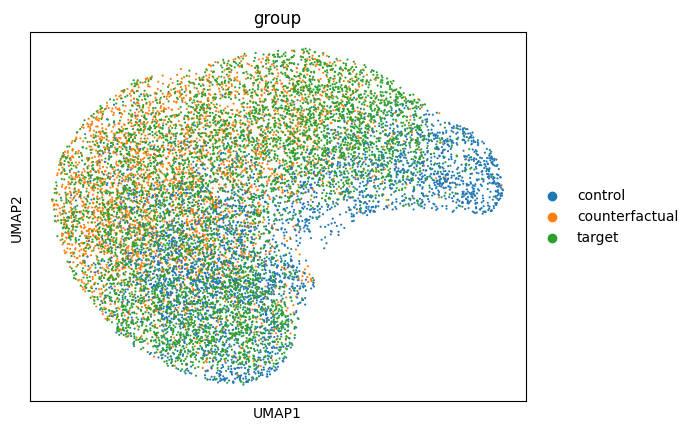

In [ ]:
# Using normalized counts
sc.pl.umap(adata_merged, color=['group'], wspace=0.4)

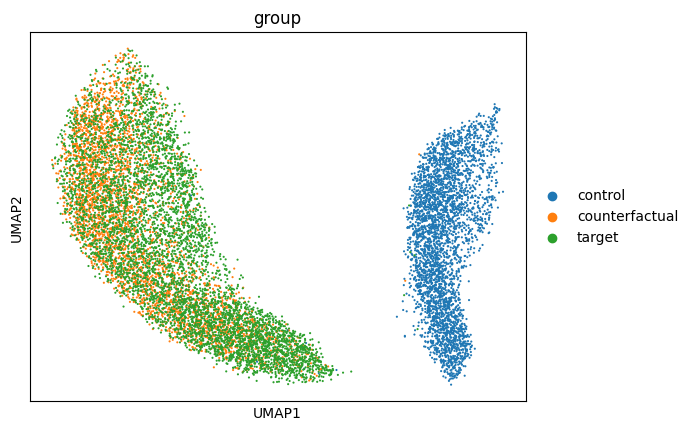

In [ ]:
# Spatial representation
sc.pl.umap(adata_merged, color=['group'], wspace=0.4)

In [ ]:
# ------------------------------
# 1. Define E-distance function
# ------------------------------
def e_distance(X, Y):
    """Compute the multivariate energy distance between two groups."""
    d_xy = cdist(X, Y, metric='euclidean')
    d_xx = cdist(X, X, metric='euclidean')
    d_yy = cdist(Y, Y, metric='euclidean')
    return 2 * np.mean(d_xy) - np.mean(d_xx) - np.mean(d_yy)

# ------------------------------
# 2. Subsample function
# ------------------------------
def subsample_cells(X, n=200, seed=None):
    """Randomly subsample rows of a matrix."""
    rng = np.random.default_rng(seed)
    if X.shape[0] > n:
        idx = rng.choice(X.shape[0], n, replace=False)
        return X[idx]
    return X


def permutation_test(X, Y, n_perms=1000, seed=None):
    """Permutation test for E-distance between X and Y."""
    rng = np.random.default_rng(seed)
    observed = e_distance(X, Y)
    combined = np.vstack([X, Y])
    n_x = X.shape[0]
    count = 0
    for _ in range(n_perms):
        rng.shuffle(combined)
        X_perm, Y_perm = combined[:n_x], combined[n_x:]
        if e_distance(X_perm, Y_perm) >= observed:
            count += 1
    pval = (count + 1) / (n_perms + 1)
    return pval

In [ ]:
# ------------------------------
# 3. Define groups and labels
# ------------------------------
groups = adata_ref.obs["omega_source"].unique()
X_dict = {g: adata_ref[adata_ref.obs["omega_source"]==g].X for g in groups}
# ------------------------------
# 4. Compute pairwise E-distances
# ------------------------------
distance_matrix = pd.DataFrame(index=groups, columns=groups, dtype=float)
n_subsample = 500  # adjust for memory

for g1 in groups:
    X1 = subsample_cells(X_dict[g1], n_subsample, seed=0)
    for g2 in groups:
        X2 = subsample_cells(X_dict[g2], n_subsample, seed=0)
        distance_matrix.loc[g1, g2] = e_distance(X1, X2)
# ------------------------------
# 5. Plot E-distance heatmap
# ------------------------------
mask = np.triu(np.ones_like(distance_matrix, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(distance_matrix.astype(float), annot=True, cmap="coolwarm", mask=mask)
plt.title("Pairwise E-Distances (Lower Triangular)")
plt.show()
# Compute p-values for upper triangle
n_perms = 2000
n_subsample = 150  # adjust for memory
pval_matrix = pd.DataFrame(np.ones_like(distance_matrix), index=groups, columns=groups, dtype=float)
for i, g1 in enumerate(groups):
    X1 = subsample_cells(X_dict[g1], n_subsample, seed=0)
    for j, g2 in enumerate(groups):
        if i < j:
            X2 = subsample_cells(X_dict[g2], n_subsample, seed=0)
            pval_matrix.loc[g1, g2] = permutation_test(X1, X2, n_perms=n_perms, seed=0)
# ------------------------------
# 7. Plot p-value heatmap (mask non-significant)
# ------------------------------
plt.figure(figsize=(8,6))
mask = pval_matrix > 0.05
sns.heatmap(pval_matrix.astype(float), annot=True, cmap="Reds", mask=None)
plt.title("Permutation Test Significance (p < 0.05)")
plt.show()

# OOD

In [45]:
# Conditions
is_fibro  = adata.obs["cell_type"].isin(["Fibroblast"])
is_stress = adata.obs["region"] == "stressed"

# Combine for test set
test_mask = (is_stress) & (is_fibro)

In [46]:
test_idx = np.where(test_mask)[0]
trainval_idx = np.where(~test_mask)[0]

In [47]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.1,
    random_state=0,
    shuffle=True,
)

In [49]:
CellinaModel.setup_anndata(adata,
                           batch_key="batch",
                           labels_key='cell_type', 
                           domains_key='region', 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


In [61]:
model = CellinaModel(
    adata, n_latent=64, classifier_lambda=1e5, discriminator_lambda=5e5, condition_on_intrinsic=False
)
model.train(
    max_epochs=epochs,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=25,
    early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
    #train_size=0.9,
    #validation_size=0.1,
    datasplitter_kwargs={
        "external_indexing": [train_idx, val_idx, test_idx],
    },
    plan_kwargs={
        "lr": 0.0001,
        "weight_decay": 0.0001,
    },
    enable_checkpointing=True,
    batch_size=2048,
    devices=[1],
)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [01:12<00:00,  1.41it/s, v_num=1, train_loss=-4.42e+5]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [01:12<00:00,  1.37it/s, v_num=1, train_loss=-4.42e+5]


In [62]:
# Combine for test set
intrinsic_mask = (is_fibro) & (is_lv)
target_mask = (is_fibro) & (is_stress)

indices_basal = np.where(intrinsic_mask)[0]
indices_counterfactual = np.where(target_mask)[0]

In [63]:
from cellina._utils import make_counterfactual_adata

adata_cf = make_counterfactual_adata(
    adata,
    indices_basal=indices_basal,
    indices_counterfactual=indices_counterfactual,
    spatial_column="spatial_x",
    sample = False
)

In [64]:
# Get normalized counterfactual expression
adata_cf.obsm['recon_x'] = model.get_normalized_expression(adata=adata_cf)
adata_cf.obsm['z'] = model.get_latent_representation(adata=adata_cf, latent_key='z')
adata_cf.obsm['s'] = model.get_latent_representation(adata=adata_cf, latent_key='s')

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


In [65]:
# Get normalized ground truth control and target expressions
adata_control = adata[intrinsic_mask].copy()
adata_control.obsm['recon_x'] = model.get_normalized_expression(adata=adata_control)
adata_control.obsm['z'] = model.get_latent_representation(adata=adata_control, latent_key='z')
adata_control.obsm['s'] = model.get_latent_representation(adata=adata_control, latent_key='s')

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


In [66]:
adata_target = adata[target_mask].copy()
adata_target.obsm['recon_x'] = model.get_normalized_expression(adata=adata_target)
adata_target.obsm['z'] = model.get_latent_representation(adata=adata_target, latent_key='z')
adata_target.obsm['s'] = model.get_latent_representation(adata=adata_target, latent_key='s')

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


In [67]:
adata_cf.obs['group'] = 'counterfactual'
adata_control.obs['group'] = 'control'
adata_target.obs['group'] = 'target'
adata_merged = adata_cf.concatenate(adata_control, adata_target)

/tmp/ipykernel_249697/4126972543.py:4: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merged = adata_cf.concatenate(adata_control, adata_target)
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['ISG15', 'TNFRSF4', 'HES5', 'AL831784.1', 'SLC2A5']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/data/a330d/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['ISG15', 'TNFRSF4', 'HES5', 'AL831784.1', 'SLC2A5']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [68]:
sc.pp.neighbors(adata_merged, use_rep='recon_x')
sc.tl.umap(adata_merged)

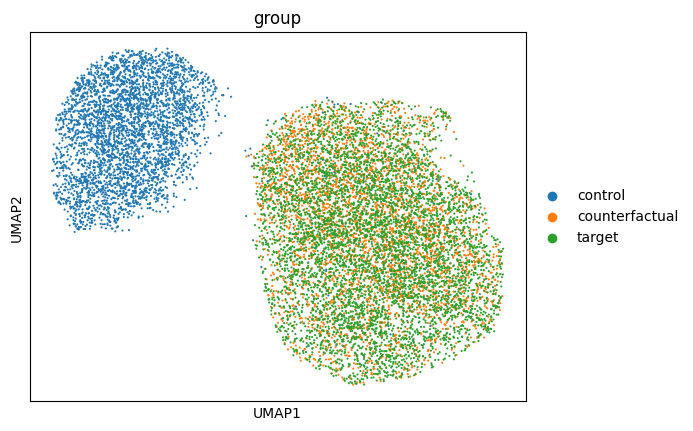

In [58]:
# Using normalized counts
sc.pl.umap(adata_merged, color=['group'], wspace=0.4)

In [69]:
sc.pp.neighbors(adata_merged, use_rep='s')
sc.tl.umap(adata_merged)

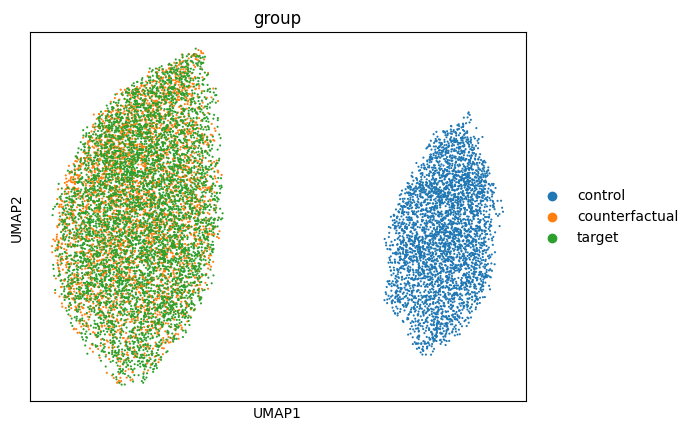

In [60]:
# Spatial representation
sc.pl.umap(adata_merged, color=['group'], wspace=0.4)

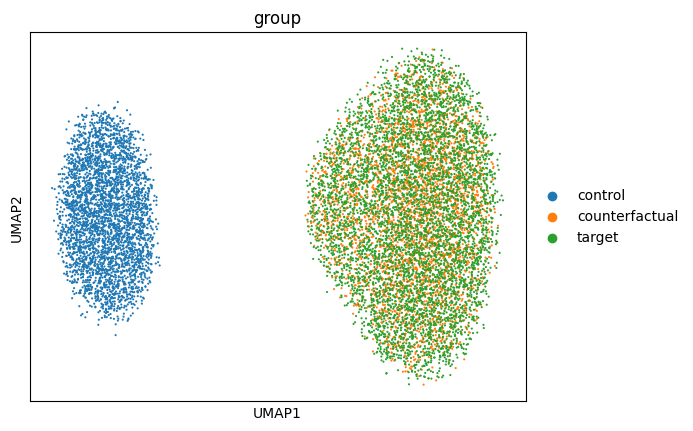

In [70]:
# Spatial representation
sc.pl.umap(adata_merged, color=['group'], wspace=0.4)